# Master Thesis — All Datasets Status & Exploration

Full snapshot of all three knee OA datasets used in the LODO study.

| Dataset | Role | Storage |
|---------|------|---------|
| **OAI** | Training / LODO fold | `My Drive/oai/screening_images/` (raw DICOMs) |
| **NHANES III** | Training / LODO fold | `My Drive/nhanes3/processed/` (processed PNGs) |
| **Mendeley OA** | **Hold-out only** | `My Drive/mendeley_oa/processed/` (processed PNGs) |

**Sections:**
1. OAI — storage, labels, match rate, samples, quality
2. NHANES III — storage, labels, split, samples, quality
3. Mendeley OA — storage, labels, samples, quality
4. Combined comparison — counts, KL distributions, image quality across datasets
5. Progress summary

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!pip install -q pydicom scikit-image

In [ ]:
from pathlib import Path
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from skimage.filters import laplace
warnings.filterwarnings('ignore')
random.seed(42)

DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT    = DRIVE_ROOT / 'Master Thesis'

OAI_IMAGE_DIR   = PROJECT / 'oai' / 'screening_images'
OAI_LABELS_CSV  = PROJECT / 'oai' / 'oai_labels.csv'

NHANES_PNG_DIR   = PROJECT / 'nhanes3' / 'processed'
NHANES_LABEL_DIR = PROJECT / 'nhanes3'

MENDELEY_PNG_DIR = PROJECT / 'mendeley_oa' / 'processed'
MENDELEY_CSV     = PROJECT / 'mendeley_oa' / 'mendeley_holdout.csv'

OUT_DIR = PROJECT / 'dataset_status'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Paths configured.')
for name, p in [
    ('OAI images',        OAI_IMAGE_DIR),
    ('OAI labels',        OAI_LABELS_CSV),
    ('NHANES PNGs',       NHANES_PNG_DIR),
    ('NHANES labels',     NHANES_LABEL_DIR),
    ('Mendeley PNGs',     MENDELEY_PNG_DIR),
    ('Mendeley holdout',  MENDELEY_CSV),
]:
    status = '✅' if p.exists() else '❌ NOT FOUND'
    print(f'  {status}  {name}: {p}')


Paths configured.
  ✅  OAI images: /content/drive/MyDrive/oai/screening_images
  ✅  OAI labels: /content/drive/MyDrive/oai/oai_labels.csv
  ✅  NHANES PNGs: /content/drive/MyDrive/nhanes3/processed
  ✅  NHANES labels: /content/drive/MyDrive/nhanes3
  ✅  Mendeley PNGs: /content/drive/MyDrive/mendeley_oa/processed
  ✅  Mendeley holdout: /content/drive/MyDrive/mendeley_oa/mendeley_holdout.csv


---
## 1 — OAI (Osteoarthritis Initiative)
Bilateral screening X-rays. Raw DICOMs, one file per subject. Labels from `KXR_SQ_BU00.txt` (READPRJ=15).

In [15]:

oai_dicoms = [p for p in OAI_IMAGE_DIR.rglob('*') if p.is_file() and p.suffix == '']
oai_sizes_mb = [p.stat().st_size / 1e6 for p in oai_dicoms]
oai_total_gb = sum(oai_sizes_mb) / 1e3

oai_subjects = set()
for p in oai_dicoms:
    parts = p.relative_to(OAI_IMAGE_DIR).parts
    if len(parts) >= 2:
        oai_subjects.add(parts[1])

print('OAI — Storage')
print('=' * 50)
print(f'  DICOM images     : {len(oai_dicoms):,}')
print(f'  Unique subjects  : {len(oai_subjects):,}')
print(f'  Total on Drive   : {oai_total_gb:.2f} GB')
print(f'  File size range  : {min(oai_sizes_mb):.1f} – {max(oai_sizes_mb):.1f} MB')
print(f'  Mean file size   : {np.mean(oai_sizes_mb):.1f} MB')

OAI — Storage
  DICOM images     : 4,796
  Unique subjects  : 4,795
  Total on Drive   : 78.95 GB
  File size range  : 7.2 – 33.9 MB
  Mean file size   : 16.5 MB


In [16]:

oai_labels = pd.read_csv(OAI_LABELS_CSV, dtype={'subject_id': str})
oai_labels['subject_id'] = oai_labels['subject_id'].str.strip()

oai_label_subjects  = set(oai_labels['subject_id'])
oai_matched         = oai_label_subjects & oai_subjects
oai_match_pct       = 100 * len(oai_matched) / len(oai_label_subjects)
oai_matched_labels  = oai_labels[oai_labels['subject_id'].isin(oai_matched)]

print('OAI — Labels')
print('=' * 50)
print(f'  Total label rows       : {len(oai_labels):,}')
print(f'  Unique label subjects  : {len(oai_label_subjects):,}')
print(f'  Matched (image+label)  : {len(oai_matched):,}  ({oai_match_pct:.1f}%)')
print(f'  Labels w/o image       : {len(oai_label_subjects - oai_subjects):,}')
print(f'  Images w/o label       : {len(oai_subjects - oai_label_subjects):,}')
print(f'  Usable knee rows       : {len(oai_matched_labels):,}')
print(f'\n  KL distribution (matched):')
oai_kl_dist = oai_matched_labels['kl_grade'].value_counts().sort_index()
for kl, n in oai_kl_dist.items():
    print(f'    KL {kl}: {n:,}')

OAI — Labels
  Total label rows       : 8,921
  Unique label subjects  : 4,490
  Matched (image+label)  : 4,490  (100.0%)
  Labels w/o image       : 0
  Images w/o label       : 305
  Usable knee rows       : 8,921

  KL distribution (matched):
    KL 0: 3,440
    KL 1: 1,588
    KL 2: 2,362
    KL 3: 1,237
    KL 4: 294


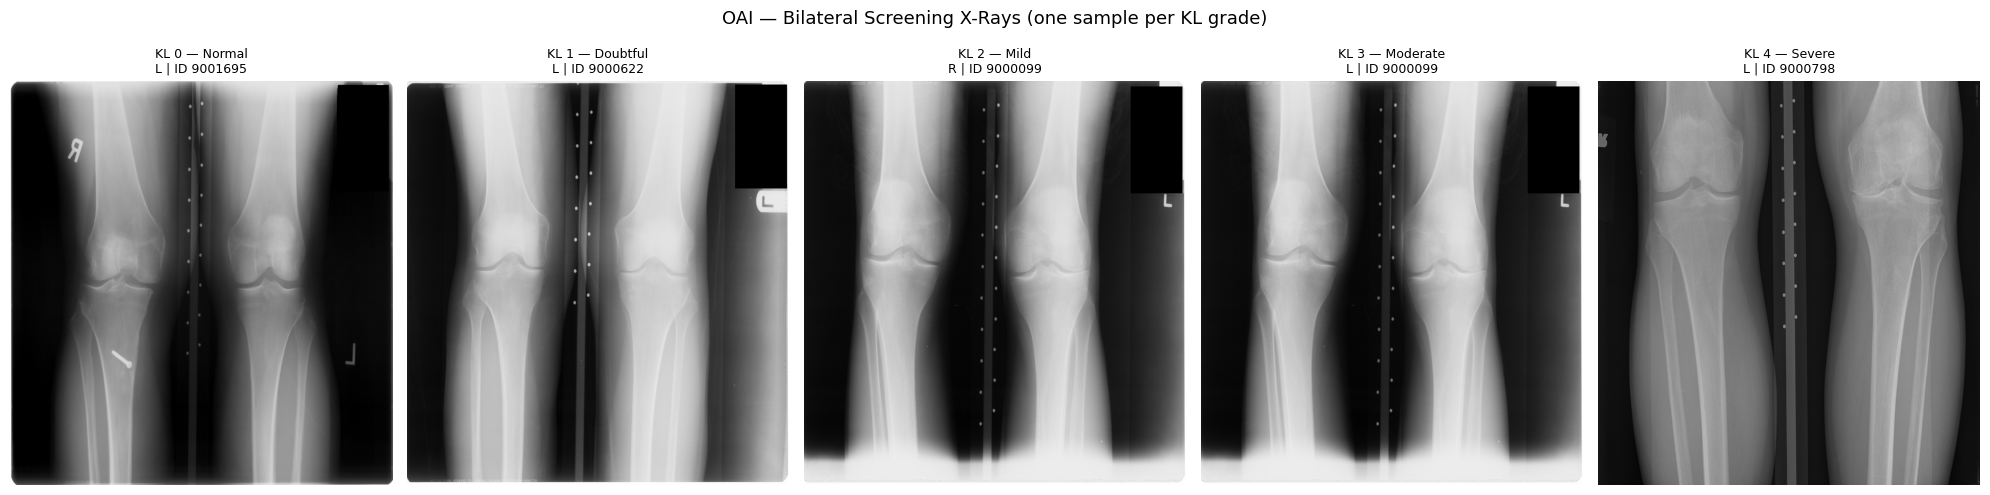

In [17]:

def load_dicom(path):
    ds  = pydicom.dcmread(str(path))
    arr = ds.pixel_array.astype(np.float32)
    arr = arr * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    arr -= arr.min()
    if arr.max() > 0:
        arr /= arr.max()
    return (arr * 255).astype(np.uint8)

oai_samples = {}
for kl in range(5):
    subset = oai_matched_labels[oai_matched_labels['kl_grade'] == kl]
    for _, row in subset.iterrows():
        sid = str(row['subject_id'])
        for p in OAI_IMAGE_DIR.rglob('*'):
            if p.is_file() and p.suffix == '' and p.relative_to(OAI_IMAGE_DIR).parts[1] == sid:
                try:
                    oai_samples[kl] = (sid, row['side'], load_dicom(p))
                    break
                except Exception:
                    pass
        if kl in oai_samples:
            break

KL_NAMES = ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, kl in zip(axes, range(5)):
    if kl in oai_samples:
        sid, side, px = oai_samples[kl]
        ax.imshow(px, cmap='gray', aspect='auto')
        ax.set_title(f'KL {kl} — {KL_NAMES[kl]}\n{side} | ID {sid}', fontsize=9)
    else:
        ax.text(0.5, 0.5, f'KL {kl}\nNo sample', ha='center', va='center', fontsize=10)
    ax.axis('off')
fig.suptitle('OAI — Bilateral Screening X-Rays (one sample per KL grade)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'oai_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:

oai_sample_paths = random.sample(oai_dicoms, min(100, len(oai_dicoms)))
oai_qrows = []
oai_corrupt = 0

for p in oai_sample_paths:
    try:
        arr = load_dicom(p)
        oai_qrows.append({
            'brightness'   : float(np.mean(arr)),
            'contrast'     : float(np.std(arr)),
            'blur'         : float(np.var(laplace(arr.astype(np.float32)))),
            'dynamic_range': float(arr.max() - arr.min()),
            'height': arr.shape[0], 'width': arr.shape[1],
        })
    except Exception:
        oai_corrupt += 1

oai_qdf = pd.DataFrame(oai_qrows)
print(f'OAI quality sample: {len(oai_qdf)}/100 readable  |  {oai_corrupt} corrupt')
resolutions = oai_qdf.groupby(['height','width']).size().reset_index(name='count').sort_values('count', ascending=False)
print('Resolutions:')
print(resolutions.to_string(index=False))
print('\nQuality stats:')
print(oai_qdf[['brightness','contrast','blur','dynamic_range']].describe().round(1).to_string())

OAI quality sample: 91/100 readable  |  9 corrupt
Resolutions:
 height  width  count
   2320   2828     29
   2048   2494     24
   1984   2492     16
   3560   4320      6
   2828   2320      3
   3481   4263      2
   1780   2348      1
   3480   4246      1
   3477   4251      1
   3481   4638      1
   3482   4622      1
   3484   4271      1
   3483   4674      1
   3485   4253      1
   3485   4369      1
   3517   4309      1
   3538   4294      1

Quality stats:
       brightness  contrast   blur  dynamic_range
count        91.0      91.0   91.0           91.0
mean         80.3      55.0   99.5          255.0
std          31.9      23.4   71.9            0.0
min          28.1      22.5   22.2          255.0
25%          57.2      33.2   42.4          255.0
50%          85.9      51.3   87.7          255.0
75%         101.6      77.9  139.8          255.0
max         182.3      98.9  396.7          255.0


---
## 2 — NHANES III
Individual knee X-rays (bilateral-split TIFFs, processed to 224×224 PNGs with CLAHE). Labels from fixed-width `xr.dat`. Person-level 70/15/15 train/val/test split.

In [19]:

nhanes_pngs = list(NHANES_PNG_DIR.glob('*.png')) if NHANES_PNG_DIR.exists() else []
nhanes_size_mb = [p.stat().st_size / 1e6 for p in nhanes_pngs]
nhanes_total_gb = sum(nhanes_size_mb) / 1e3

print('NHANES III — Storage')
print('=' * 50)
print(f'  Processed PNGs   : {len(nhanes_pngs):,}')
print(f'  Total on Drive   : {nhanes_total_gb:.3f} GB  ({sum(nhanes_size_mb):.1f} MB)')
if nhanes_size_mb:
    print(f'  File size range  : {min(nhanes_size_mb):.2f} – {max(nhanes_size_mb):.2f} MB')
    print(f'  Mean file size   : {np.mean(nhanes_size_mb):.3f} MB')

NHANES III — Storage
  Processed PNGs   : 9,810
  Total on Drive   : 0.208 GB  (208.0 MB)
  File size range  : 0.02 – 0.03 MB
  Mean file size   : 0.021 MB


In [20]:

nhanes_split_csv = NHANES_LABEL_DIR / 'labels_split.csv'
nhanes_all_csv   = NHANES_LABEL_DIR / 'labels_all.csv'

if nhanes_split_csv.exists():
    nhanes_labels = pd.read_csv(nhanes_split_csv)
    has_split = True
elif nhanes_all_csv.exists():
    nhanes_labels = pd.read_csv(nhanes_all_csv)
    has_split = False
    print('WARNING: labels_split.csv not found — using labels_all.csv (no split column)')
else:
    nhanes_labels = pd.DataFrame()
    has_split = False
    print('WARNING: No NHANES label CSV found. Run nhanes3_labels.ipynb first.')

if len(nhanes_labels) > 0:
    nhanes_kl_dist = nhanes_labels['kl_grade'].value_counts().sort_index()
    print('NHANES III — Labels')
    print('=' * 50)
    print(f'  Total label rows  : {len(nhanes_labels):,}')
    print(f'  Unique persons    : {nhanes_labels["seqn"].nunique():,}')
    print(f'\n  KL distribution:')
    for kl, n in nhanes_kl_dist.items():
        print(f'    KL {kl}: {n:,}')
    if has_split:
        print('\n  Split breakdown:')
        split_tbl = nhanes_labels.groupby(['split','kl_grade']).size().unstack(fill_value=0)
        print(split_tbl.to_string())
        split_totals = nhanes_labels['split'].value_counts()
        total = len(nhanes_labels)
        for sp, n in split_totals.items():
            print(f'    {sp}: {n:,} ({100*n/total:.1f}%)')

NHANES III — Labels
  Total label rows  : 4,785
  Unique persons    : 2,412

  KL distribution:
    KL 0: 2,563
    KL 1: 546
    KL 2: 1,271
    KL 3: 307
    KL 4: 98

  Split breakdown:
kl_grade     0    1    2    3   4
split                            
test       388   78  195   43  14
train     1794  384  886  213  73
val        381   84  190   51  11
    train: 3,350 (70.0%)
    test: 718 (15.0%)
    val: 717 (15.0%)


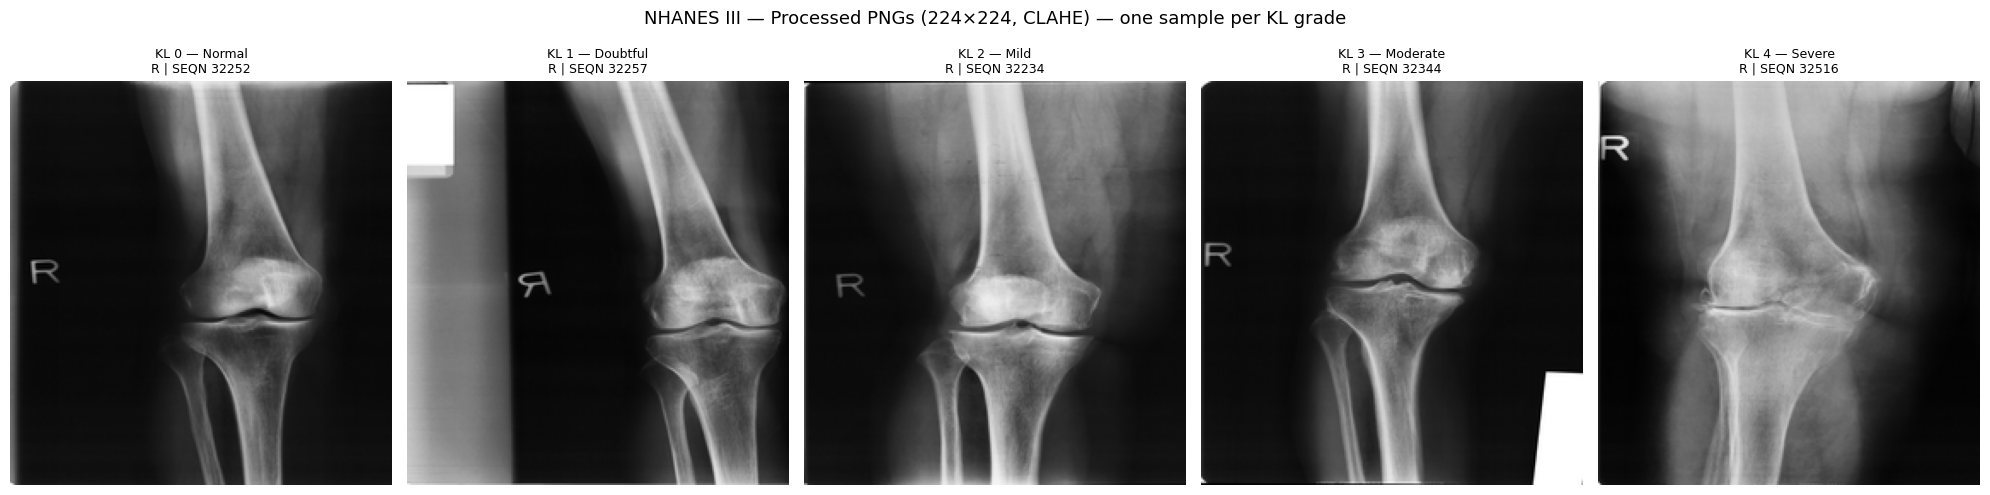

In [21]:

def load_png(path):
    return np.array(Image.open(str(path)).convert('L'))

nhanes_samples = {}
if len(nhanes_labels) > 0 and len(nhanes_pngs) > 0:
    existing_names = {p.name: p for p in nhanes_pngs}
    for kl in range(5):
        subset = nhanes_labels[nhanes_labels['kl_grade'] == kl]
        for _, row in subset.iterrows():
            fname = row['filename']
            if fname in existing_names:
                try:
                    nhanes_samples[kl] = (row['seqn'], row['side'], load_png(existing_names[fname]))
                    break
                except Exception:
                    pass

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, kl in zip(axes, range(5)):
    if kl in nhanes_samples:
        seqn, side, px = nhanes_samples[kl]
        ax.imshow(px, cmap='gray', aspect='auto')
        ax.set_title(f'KL {kl} — {KL_NAMES[kl]}\n{side} | SEQN {seqn}', fontsize=9)
    else:
        ax.text(0.5, 0.5, f'KL {kl}\nNo sample', ha='center', va='center', fontsize=10)
    ax.axis('off')
fig.suptitle('NHANES III — Processed PNGs (224×224, CLAHE) — one sample per KL grade', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nhanes3_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:

nhanes_q_sample = random.sample(nhanes_pngs, min(100, len(nhanes_pngs)))
nhanes_qrows = []
nhanes_corrupt = 0

for p in nhanes_q_sample:
    try:
        arr = load_png(p)
        nhanes_qrows.append({
            'brightness'   : float(np.mean(arr)),
            'contrast'     : float(np.std(arr)),
            'blur'         : float(np.var(laplace(arr.astype(np.float32)))),
            'dynamic_range': float(arr.max() - arr.min()),
        })
    except Exception:
        nhanes_corrupt += 1

nhanes_qdf = pd.DataFrame(nhanes_qrows)
print(f'NHANES quality sample: {len(nhanes_qdf)}/100 readable  |  {nhanes_corrupt} corrupt')
if len(nhanes_qdf):
    print(nhanes_qdf[['brightness','contrast','blur','dynamic_range']].describe().round(1).to_string())

NHANES quality sample: 100/100 readable  |  0 corrupt
       brightness  contrast   blur  dynamic_range
count       100.0     100.0  100.0          100.0
mean         76.5      65.8  318.3          250.7
std          16.5       8.8  158.6            7.9
min          43.3      41.8   38.5          222.0
25%          64.6      59.0  197.8          249.0
50%          77.1      67.8  289.8          255.0
75%          86.3      73.0  420.6          255.0
max         125.5      81.1  801.9          255.0


---
## 3 — Mendeley OA ⚠ HOLD-OUT ONLY
Pre-cropped individual knee X-rays. Already split into train/val/test by dataset provider (used only for reference). Processed to 224×224 PNGs with CLAHE. **Never used for training.**

In [23]:

mendeley_pngs = list(MENDELEY_PNG_DIR.glob('*.png')) if MENDELEY_PNG_DIR.exists() else []
mendeley_size_mb = [p.stat().st_size / 1e6 for p in mendeley_pngs]
mendeley_total_gb = sum(mendeley_size_mb) / 1e3

print('Mendeley OA — Storage (HOLD-OUT ONLY)')
print('=' * 50)
print(f'  Processed PNGs   : {len(mendeley_pngs):,}')
print(f'  Total on Drive   : {mendeley_total_gb:.3f} GB  ({sum(mendeley_size_mb):.1f} MB)')
if mendeley_size_mb:
    print(f'  File size range  : {min(mendeley_size_mb):.3f} – {max(mendeley_size_mb):.3f} MB')
    print(f'  Mean file size   : {np.mean(mendeley_size_mb):.3f} MB')

Mendeley OA — Storage (HOLD-OUT ONLY)
  Processed PNGs   : 8,260
  Total on Drive   : 0.232 GB  (232.4 MB)
  File size range  : 0.017 – 0.037 MB
  Mean file size   : 0.028 MB


In [24]:

if MENDELEY_CSV.exists():
    mendeley_labels = pd.read_csv(MENDELEY_CSV)
    mendeley_kl_dist = mendeley_labels['kl_grade'].value_counts().sort_index()
    print('Mendeley OA — Labels')
    print('=' * 50)
    print(f'  Total images         : {len(mendeley_labels):,}')
    print(f'  Source splits (orig) : {mendeley_labels["source_split"].value_counts().to_dict()}')
    print(f'\n  KL distribution:')
    for kl, n in mendeley_kl_dist.items():
        print(f'    KL {kl}: {n:,}')
else:
    mendeley_labels  = pd.DataFrame()
    mendeley_kl_dist = pd.Series(dtype=int)
    print('WARNING: mendeley_holdout.csv not found. Run mendeley_download.ipynb first.')

Mendeley OA — Labels
  Total images         : 8,260
  Source splits (orig) : {'train': 5778, 'test': 1656, 'val': 826}

  KL distribution:
    KL 0: 3,253
    KL 1: 1,495
    KL 2: 2,175
    KL 3: 1,086
    KL 4: 251


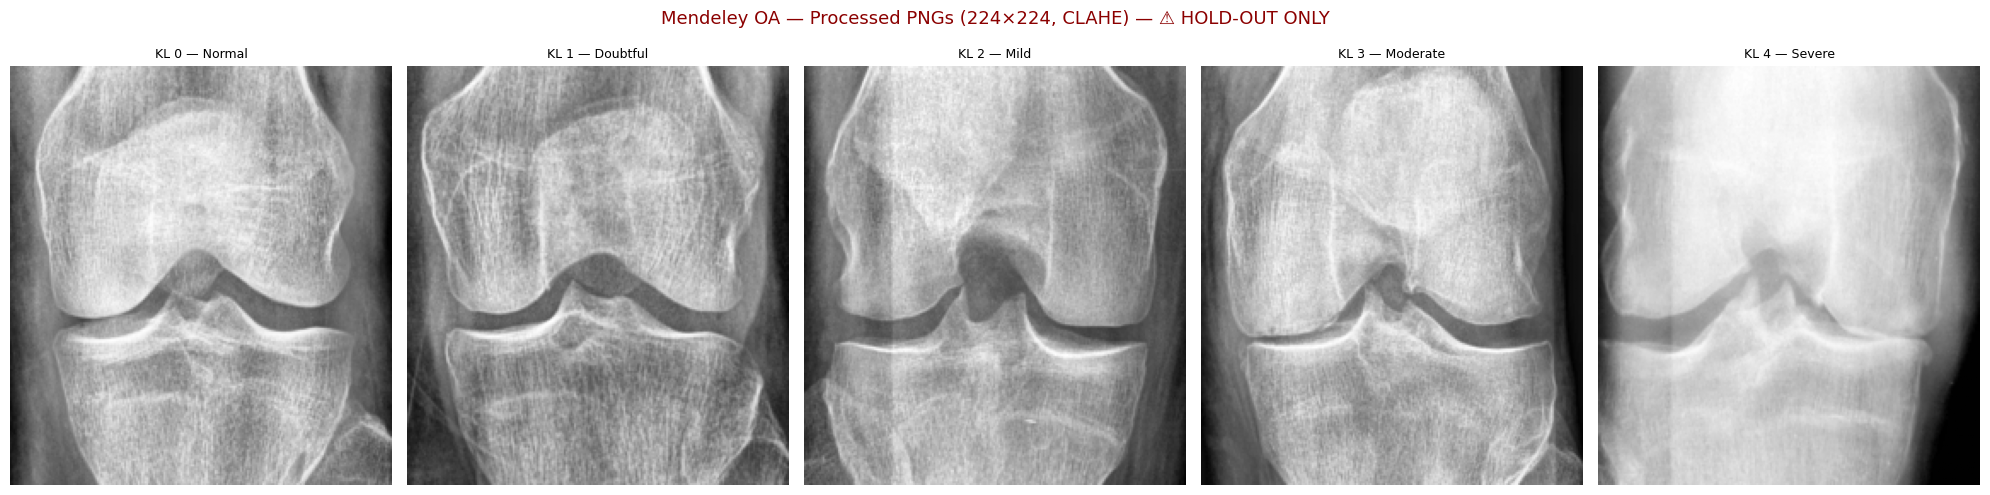

In [25]:

mendeley_samples = {}
if len(mendeley_labels) > 0 and len(mendeley_pngs) > 0:
    existing_names = {p.name: p for p in mendeley_pngs}
    for kl in range(5):
        subset = mendeley_labels[mendeley_labels['kl_grade'] == kl]
        for _, row in subset.iterrows():
            fname = row['filename']
            if fname in existing_names:
                try:
                    mendeley_samples[kl] = load_png(existing_names[fname])
                    break
                except Exception:
                    pass

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, kl in zip(axes, range(5)):
    if kl in mendeley_samples:
        ax.imshow(mendeley_samples[kl], cmap='gray', aspect='auto')
        ax.set_title(f'KL {kl} — {KL_NAMES[kl]}', fontsize=9)
    else:
        ax.text(0.5, 0.5, f'KL {kl}\nNo sample', ha='center', va='center', fontsize=10)
    ax.axis('off')
fig.suptitle('Mendeley OA — Processed PNGs (224×224, CLAHE) — ⚠ HOLD-OUT ONLY', fontsize=13, color='darkred')
plt.tight_layout()
plt.savefig(OUT_DIR / 'mendeley_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:

mendeley_q_sample = random.sample(mendeley_pngs, min(100, len(mendeley_pngs)))
mendeley_qrows = []
mendeley_corrupt = 0

for p in mendeley_q_sample:
    try:
        arr = load_png(p)
        mendeley_qrows.append({
            'brightness'   : float(np.mean(arr)),
            'contrast'     : float(np.std(arr)),
            'blur'         : float(np.var(laplace(arr.astype(np.float32)))),
            'dynamic_range': float(arr.max() - arr.min()),
        })
    except Exception:
        mendeley_corrupt += 1

mendeley_qdf = pd.DataFrame(mendeley_qrows)
print(f'Mendeley quality sample: {len(mendeley_qdf)}/100 readable  |  {mendeley_corrupt} corrupt')
if len(mendeley_qdf):
    print(mendeley_qdf[['brightness','contrast','blur','dynamic_range']].describe().round(1).to_string())

Mendeley quality sample: 100/100 readable  |  0 corrupt
       brightness  contrast   blur  dynamic_range
count       100.0     100.0  100.0          100.0
mean        152.9      40.9  321.9          206.1
std          24.4      11.5  192.4           35.7
min          66.3      11.7   46.1           86.0
25%         143.0      32.5  123.0          186.8
50%         156.4      39.0  325.4          213.5
75%         164.9      49.2  456.3          237.0
max         200.8      70.7  802.1          251.0


---
## 4 — Combined Comparison

In [27]:

summary_rows = [
    {
        'Dataset'     : 'OAI',
        'Role'        : 'Training / LODO fold',
        'Image type'  : 'DICOM (bilateral)',
        'Images'      : len(oai_dicoms),
        'Knee rows'   : len(oai_matched_labels),
        'Subjects'    : len(oai_subjects),
        'Size (GB)'   : round(oai_total_gb, 2),
        'Preprocessed': 'No (raw DICOM)',
    },
    {
        'Dataset'     : 'NHANES III',
        'Role'        : 'Training / LODO fold',
        'Image type'  : 'PNG 224×224',
        'Images'      : len(nhanes_pngs),
        'Knee rows'   : len(nhanes_labels),
        'Subjects'    : nhanes_labels['seqn'].nunique() if len(nhanes_labels) else 0,
        'Size (GB)'   : round(nhanes_total_gb, 3),
        'Preprocessed': 'Yes (CLAHE, resize)',
    },
    {
        'Dataset'     : 'Mendeley OA',
        'Role'        : '⚠ Hold-out only',
        'Image type'  : 'PNG 224×224',
        'Images'      : len(mendeley_pngs),
        'Knee rows'   : len(mendeley_labels),
        'Subjects'    : len(mendeley_labels),
        'Size (GB)'   : round(mendeley_total_gb, 3),
        'Preprocessed': 'Yes (CLAHE, resize)',
    },
]

summary_df = pd.DataFrame(summary_rows)
print('=== Dataset Overview ===')
print(summary_df.to_string(index=False))

total_knee_rows = (
    len(oai_matched_labels) +
    len(nhanes_labels) +
    len(mendeley_labels)
)
print(f'\nTotal knee label rows across all datasets: {total_knee_rows:,}')

=== Dataset Overview ===
    Dataset                 Role        Image type  Images  Knee rows  Subjects  Size (GB)        Preprocessed
        OAI Training / LODO fold DICOM (bilateral)    4796       8921      4795     78.950      No (raw DICOM)
 NHANES III Training / LODO fold       PNG 224×224    9810       4785      2412      0.208 Yes (CLAHE, resize)
Mendeley OA      ⚠ Hold-out only       PNG 224×224    8260       8260      8260      0.232 Yes (CLAHE, resize)

Total knee label rows across all datasets: 21,966


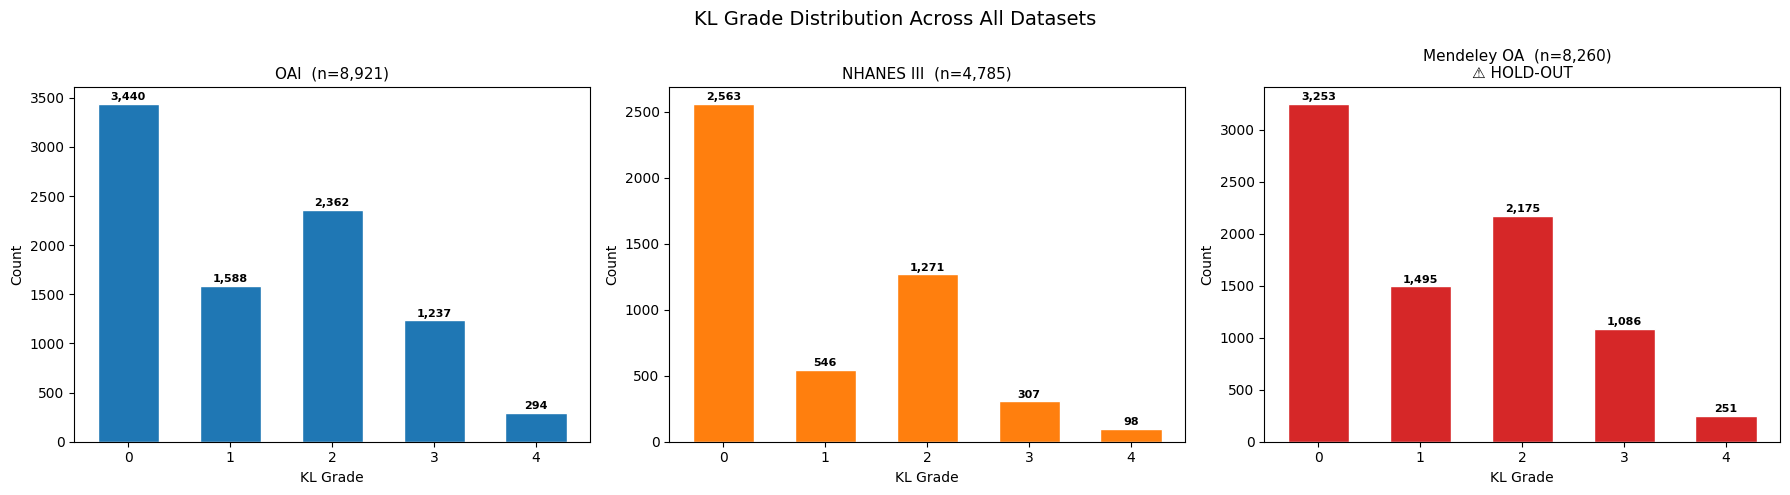

In [28]:

datasets = {
    'OAI'        : oai_matched_labels['kl_grade'].value_counts().sort_index() if len(oai_matched_labels) else pd.Series(dtype=int),
    'NHANES III' : nhanes_labels['kl_grade'].value_counts().sort_index()      if len(nhanes_labels)      else pd.Series(dtype=int),
    'Mendeley OA': mendeley_kl_dist,
}

colors_ds = {'OAI': '#1f77b4', 'NHANES III': '#ff7f0e', 'Mendeley OA': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (name, dist) in zip(axes, datasets.items()):
    if len(dist) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(name)
        continue
    c = colors_ds[name]
    bars = ax.bar(dist.index, dist.values, color=c, edgecolor='white', width=0.6)
    ax.set_xlabel('KL Grade')
    ax.set_ylabel('Count')
    hold = '  \n⚠ HOLD-OUT' if name == 'Mendeley OA' else ''
    ax.set_title(f'{name}  (n={dist.sum():,}){hold}', fontsize=11)
    for bar, v in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + dist.max()*0.01,
                f'{v:,}', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(range(5))

fig.suptitle('KL Grade Distribution Across All Datasets', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / 'all_datasets_kl_distribution.png', dpi=150)
plt.show()

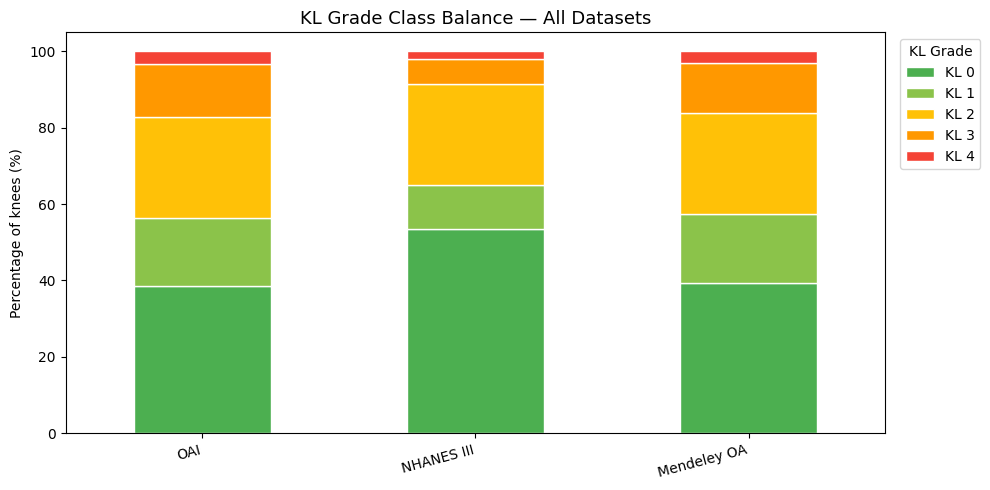

In [29]:

kl_pcts = {}
for name, dist in datasets.items():
    if len(dist) > 0:
        kl_pcts[name] = (dist / dist.sum() * 100).reindex(range(5), fill_value=0)

if kl_pcts:
    pct_df = pd.DataFrame(kl_pcts).T
    colors_kl = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
    ax = pct_df.plot(kind='bar', stacked=True, figsize=(10, 5),
                     color=colors_kl, edgecolor='white')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage of knees (%)')
    ax.set_title('KL Grade Class Balance — All Datasets', fontsize=13)
    ax.legend([f'KL {i}' for i in range(5)], title='KL Grade', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'all_datasets_class_balance.png', dpi=150, bbox_inches='tight')
    plt.show()

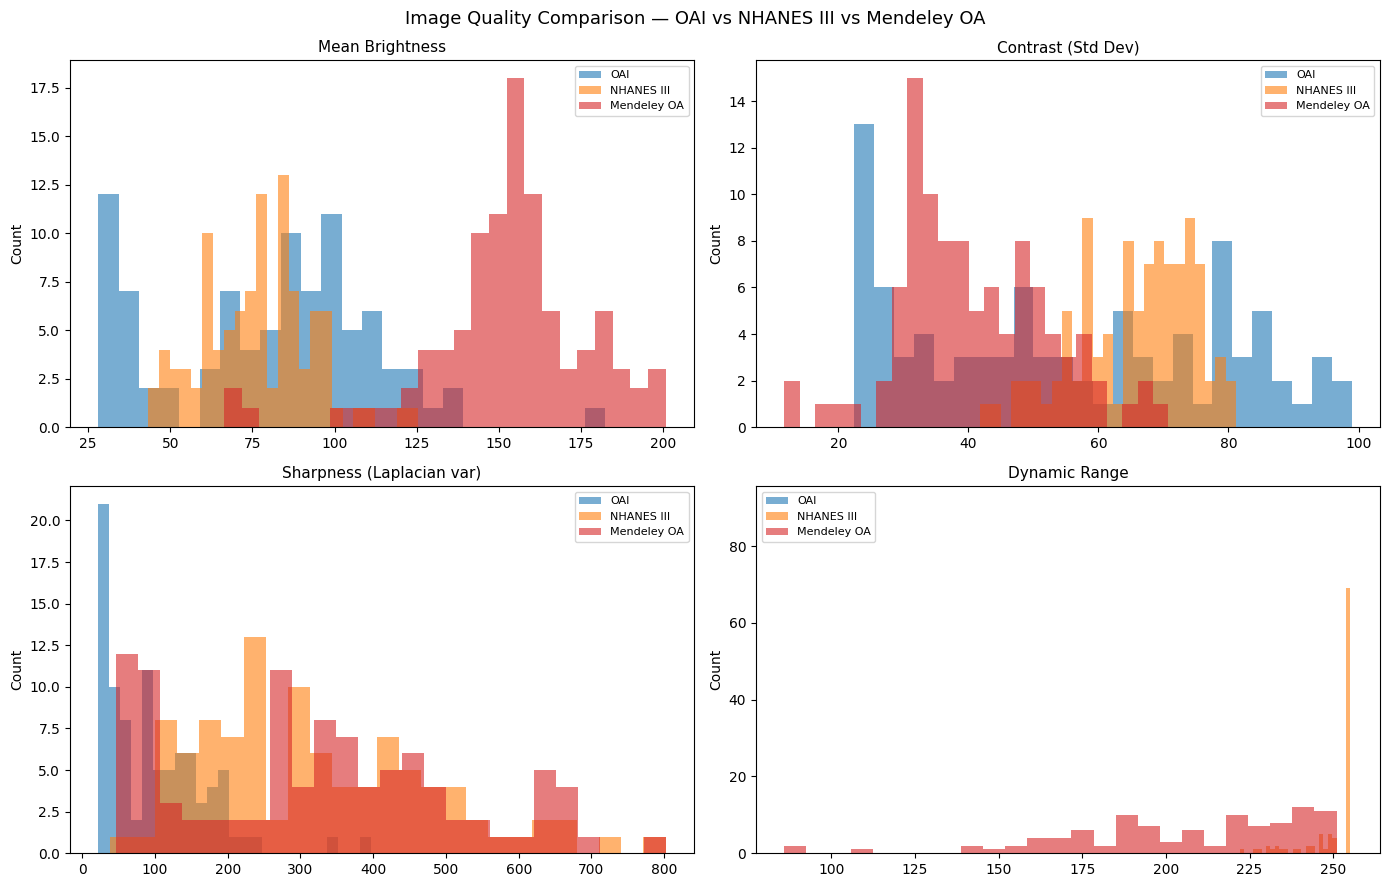

Quality summary per dataset:
             brightness  contrast   blur  dynamic_range
dataset                                                
Mendeley OA       152.9      40.9  321.9          206.1
NHANES III         76.5      65.8  318.3          250.7
OAI                80.3      55.0   99.5          255.0


In [30]:

all_qdf_list = []
for name, qdf in [('OAI', oai_qdf), ('NHANES III', nhanes_qdf), ('Mendeley OA', mendeley_qdf)]:
    if len(qdf):
        tmp = qdf[['brightness', 'contrast', 'blur', 'dynamic_range']].copy()
        tmp['dataset'] = name
        all_qdf_list.append(tmp)

if all_qdf_list:
    all_qdf = pd.concat(all_qdf_list, ignore_index=True)

    metrics = [
        ('brightness',    'Mean Brightness',   'orange'),
        ('contrast',      'Contrast (Std Dev)', 'steelblue'),
        ('blur',          'Sharpness (Laplacian var)', 'green'),
        ('dynamic_range', 'Dynamic Range',      'purple'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    ds_names  = all_qdf['dataset'].unique()
    ds_colors = {'OAI': '#1f77b4', 'NHANES III': '#ff7f0e', 'Mendeley OA': '#d62728'}

    for ax, (col, title, _) in zip(axes, metrics):
        for ds in ds_names:
            data = all_qdf[all_qdf['dataset'] == ds][col].dropna()
            ax.hist(data, bins=25, alpha=0.6, label=ds, color=ds_colors.get(ds, 'gray'), edgecolor='none')
        ax.set_title(title, fontsize=11)
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)

    fig.suptitle('Image Quality Comparison — OAI vs NHANES III vs Mendeley OA', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'all_datasets_quality_comparison.png', dpi=150)
    plt.show()

    print('Quality summary per dataset:')
    print(all_qdf.groupby('dataset')[['brightness','contrast','blur','dynamic_range']].mean().round(1).to_string())

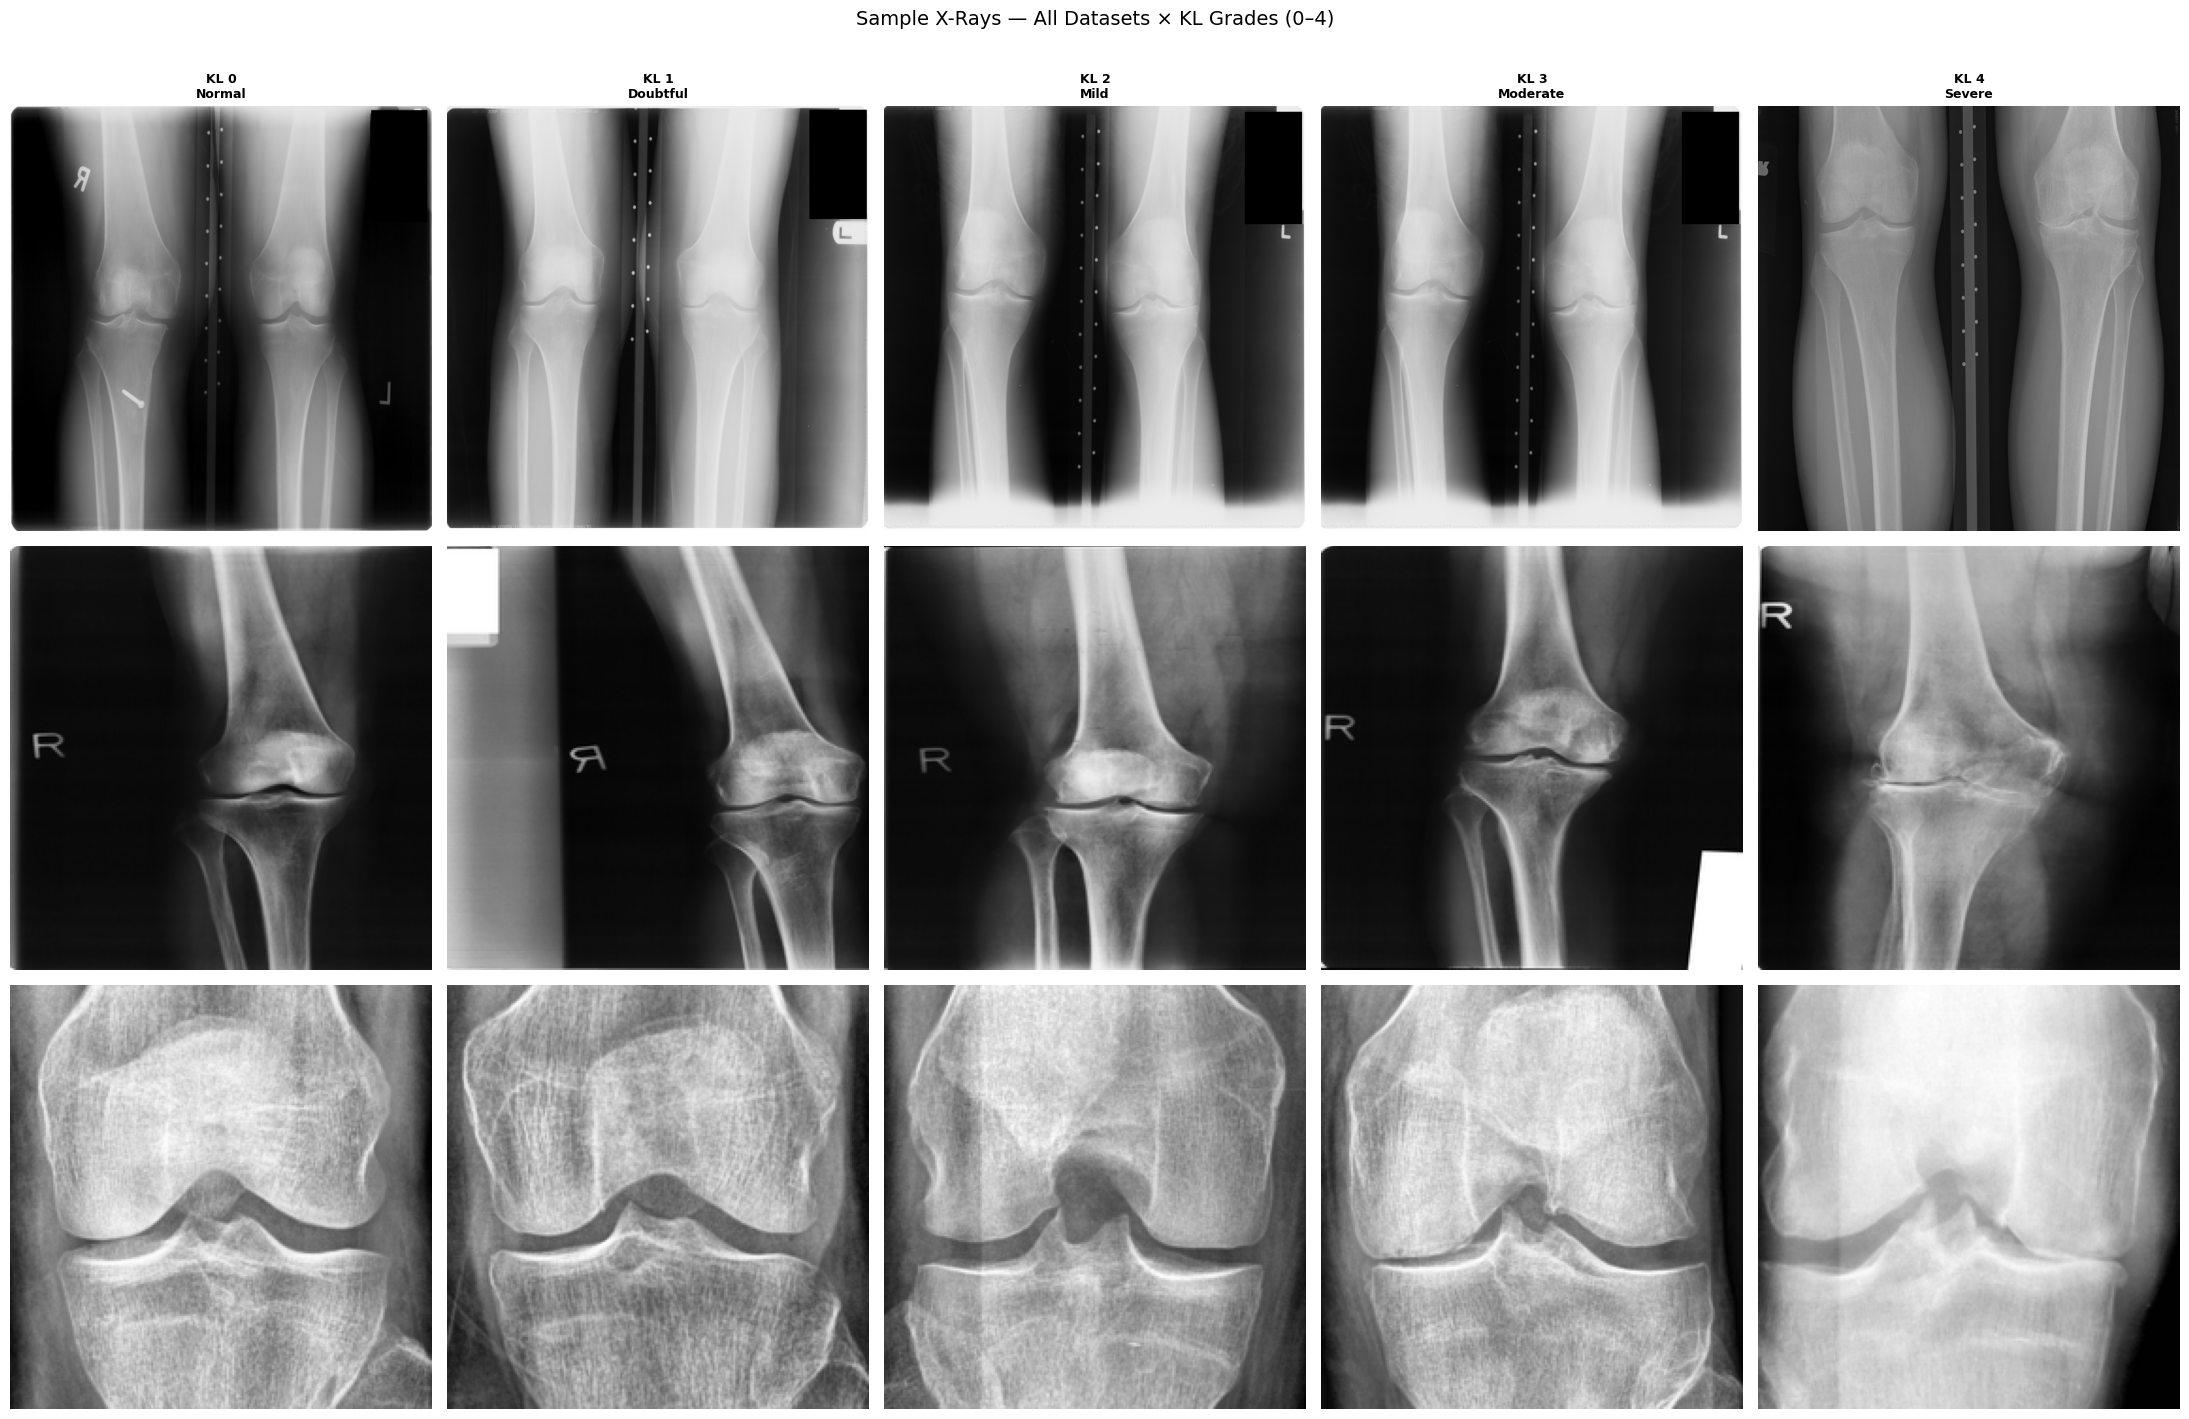

In [32]:

fig, axes = plt.subplots(3, 5, figsize=(22, 14))

row_data = [
    ('OAI',         oai_samples,      lambda d: d[2] if d else None,  'bilateral DICOM'),
    ('NHANES III',  nhanes_samples,   lambda d: d[2] if d else None,  'CLAHE PNG 224×224'),
    ('Mendeley OA', mendeley_samples, lambda d: d    if d is not None else None,  '⚠ HOLD-OUT | CLAHE PNG 224×224'),
]

for row_idx, (ds_name, samples, getter, subtitle) in enumerate(row_data):
    for kl in range(5):
        ax = axes[row_idx][kl]
        img = getter(samples.get(kl))
        if img is not None:
            ax.imshow(img, cmap='gray', aspect='auto')
            if row_idx == 0:
                ax.set_title(f'KL {kl}\n{KL_NAMES[kl]}', fontsize=9, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=9)
            if row_idx == 0:
                ax.set_title(f'KL {kl}\n{KL_NAMES[kl]}', fontsize=9, fontweight='bold')
        if kl == 0:
            ax.set_ylabel(f'{ds_name}\n{subtitle}', fontsize=8, labelpad=4)
        ax.axis('off')

fig.suptitle('Sample X-Rays — All Datasets × KL Grades (0–4)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'all_datasets_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()